# Practical Work 5 — Data Classification Models

**Datasets:**
- Breast Cancer Wisconsin (Diagnostic): https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Heart Disease: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

**Tasks:** Data Exploration → Preprocessing → Splitting (70/10/20, K-fold) → Classification Models → Evaluation → Model Comparison

## 1. Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
# Load Breast Cancer Wisconsin (Diagnostic) — built-in sklearn
bc = load_breast_cancer(as_frame=True)
df_bc = bc.frame
df_bc['target'] = (df_bc['target'] == 0).astype(int)  # 0=malignant, 1=benign (flip for clarity: 1=disease)
print("Breast Cancer:", df_bc.shape)
df_bc.head()

Breast Cancer: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [3]:
# Load Heart Disease — heart.csv (UCI Cleveland format)
# Download from: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
# Or use UCI: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/
heart_path = Path('heart.csv')
if heart_path.exists():
    df_heart = pd.read_csv(heart_path)
else:
    HEART_COLUMNS = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
    df_heart = pd.read_csv(url, header=None, names=HEART_COLUMNS).replace('?', np.nan)
    for c in ['ca', 'thal']:
        df_heart[c] = pd.to_numeric(df_heart[c], errors='coerce')
    df_heart['target'] = (df_heart['target'] > 0).astype(int)
print("Heart Disease:", df_heart.shape)
df_heart.head()

Heart Disease: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Data Exploration

Visualize feature relationships: histograms, pairplots, correlation heatmaps.

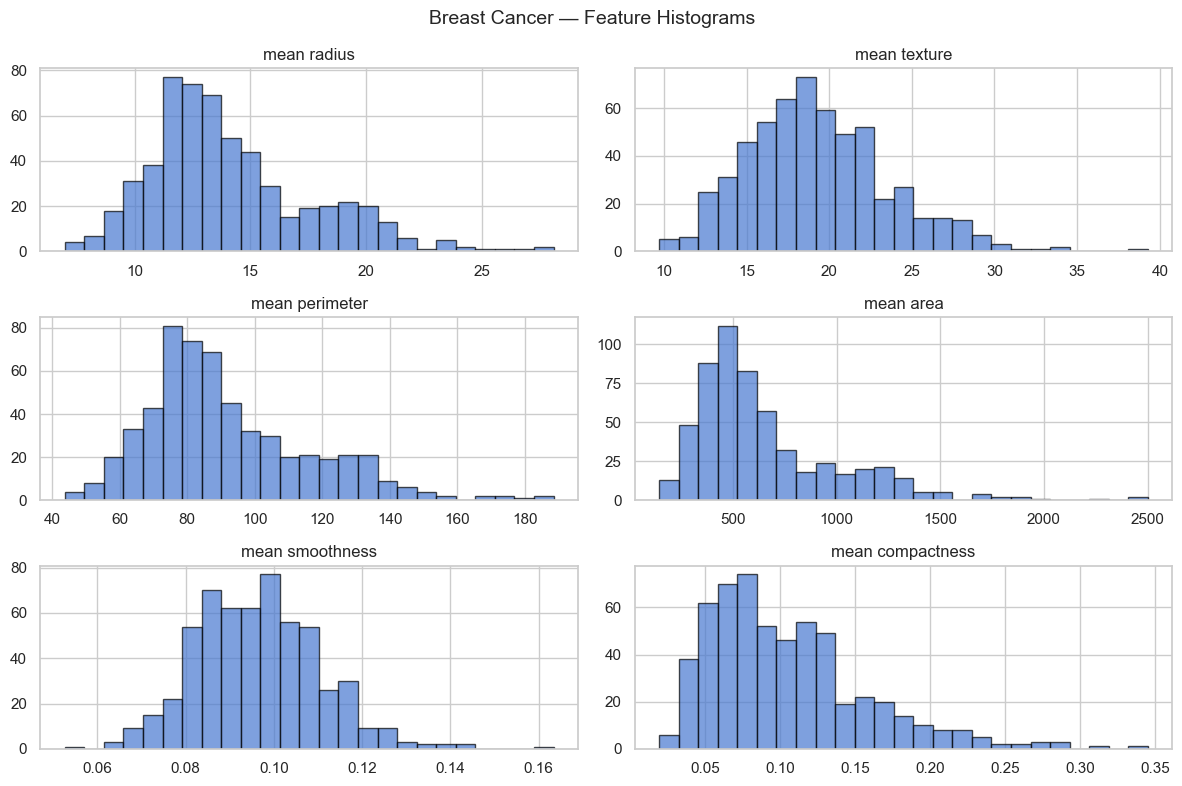

In [4]:
# Breast Cancer — Histograms of selected features
feat_bc = [c for c in df_bc.columns if c != 'target'][:6]
df_bc[feat_bc].hist(bins=25, figsize=(12, 8), edgecolor='black', alpha=0.7)
plt.suptitle('Breast Cancer — Feature Histograms', fontsize=14)
plt.tight_layout()
plt.show()

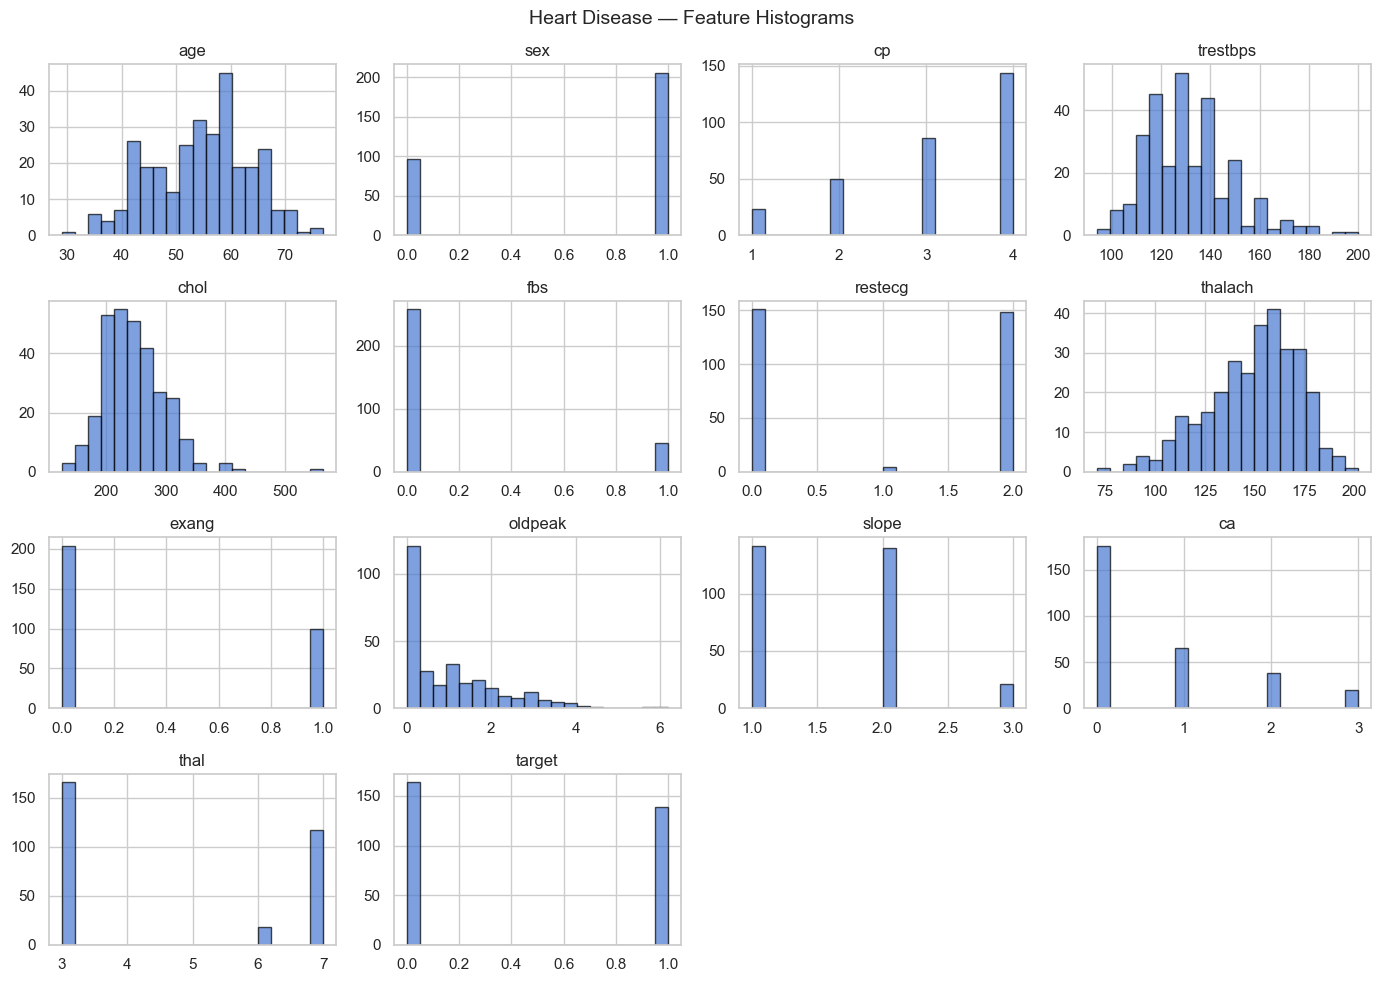

In [5]:
# Heart Disease — Histograms
df_heart.hist(bins=20, figsize=(14, 10), edgecolor='black', alpha=0.7)
plt.suptitle('Heart Disease — Feature Histograms', fontsize=14)
plt.tight_layout()
plt.show()

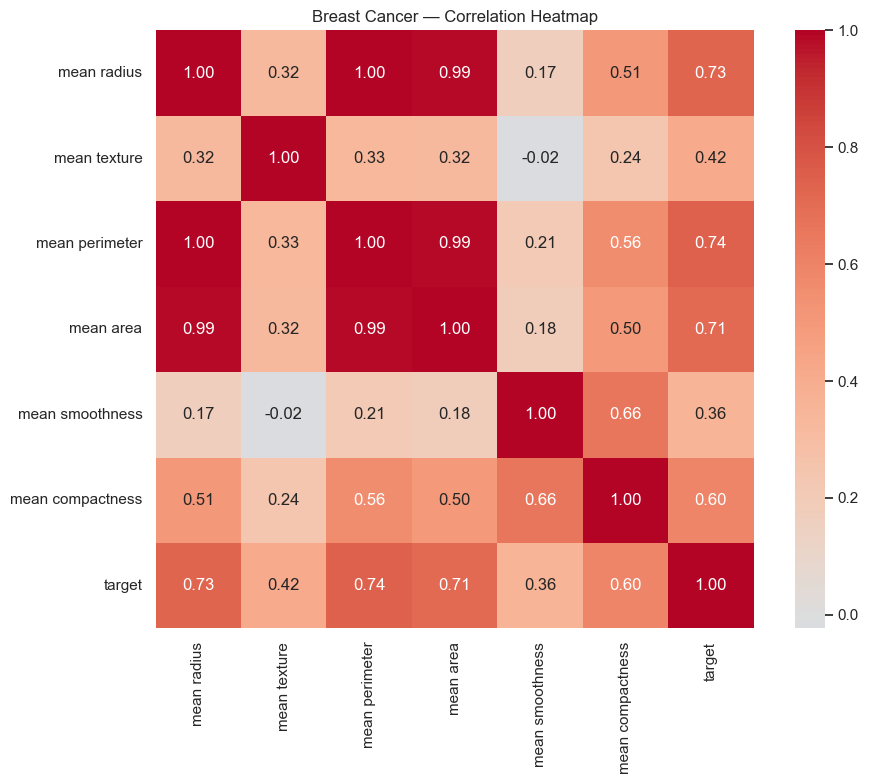

In [6]:
# Breast Cancer — Correlation heatmap (subset of features)
plt.figure(figsize=(10, 8))
corr_bc = df_bc[feat_bc + ['target']].corr()
sns.heatmap(corr_bc, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Breast Cancer — Correlation Heatmap')
plt.tight_layout()
plt.show()

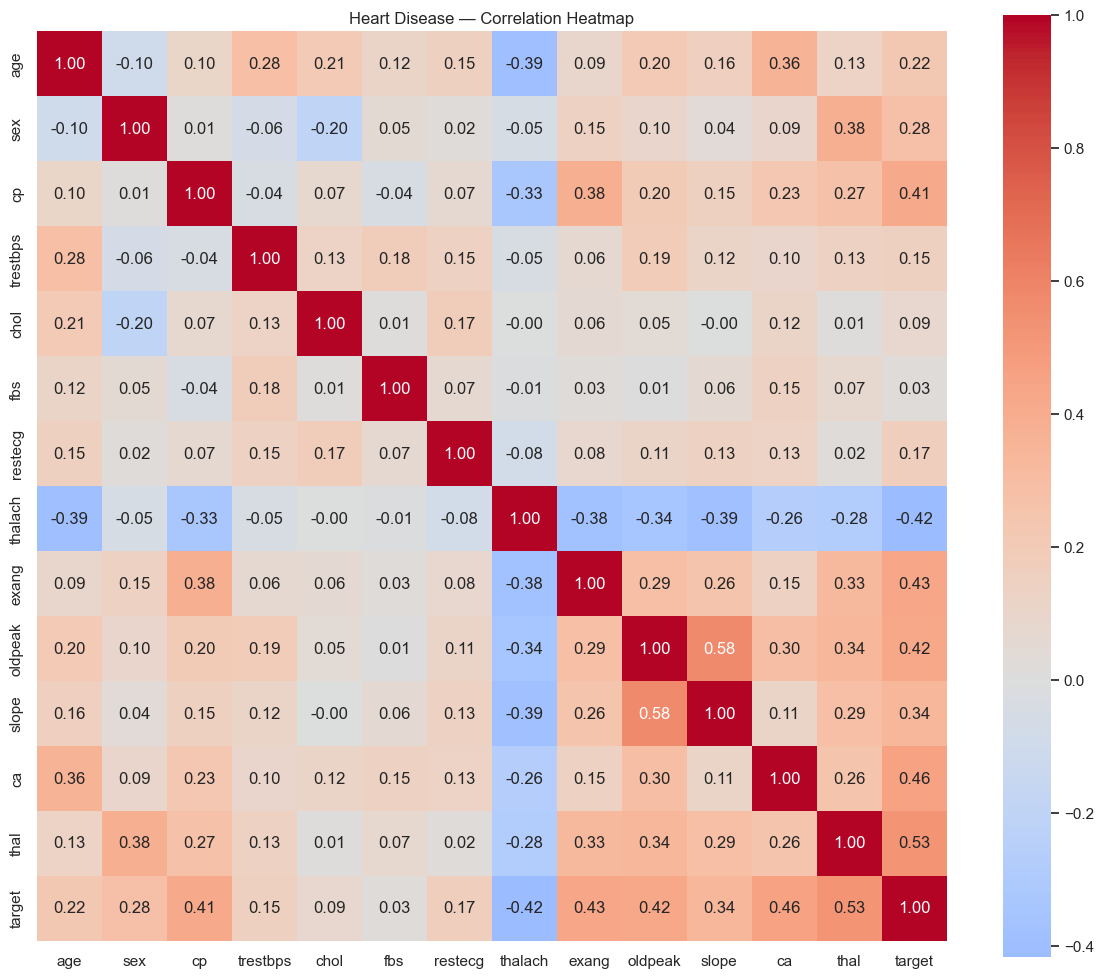

In [7]:
# Heart Disease — Correlation heatmap
plt.figure(figsize=(12, 10))
corr_heart = df_heart.corr()
sns.heatmap(corr_heart, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Heart Disease — Correlation Heatmap')
plt.tight_layout()
plt.show()

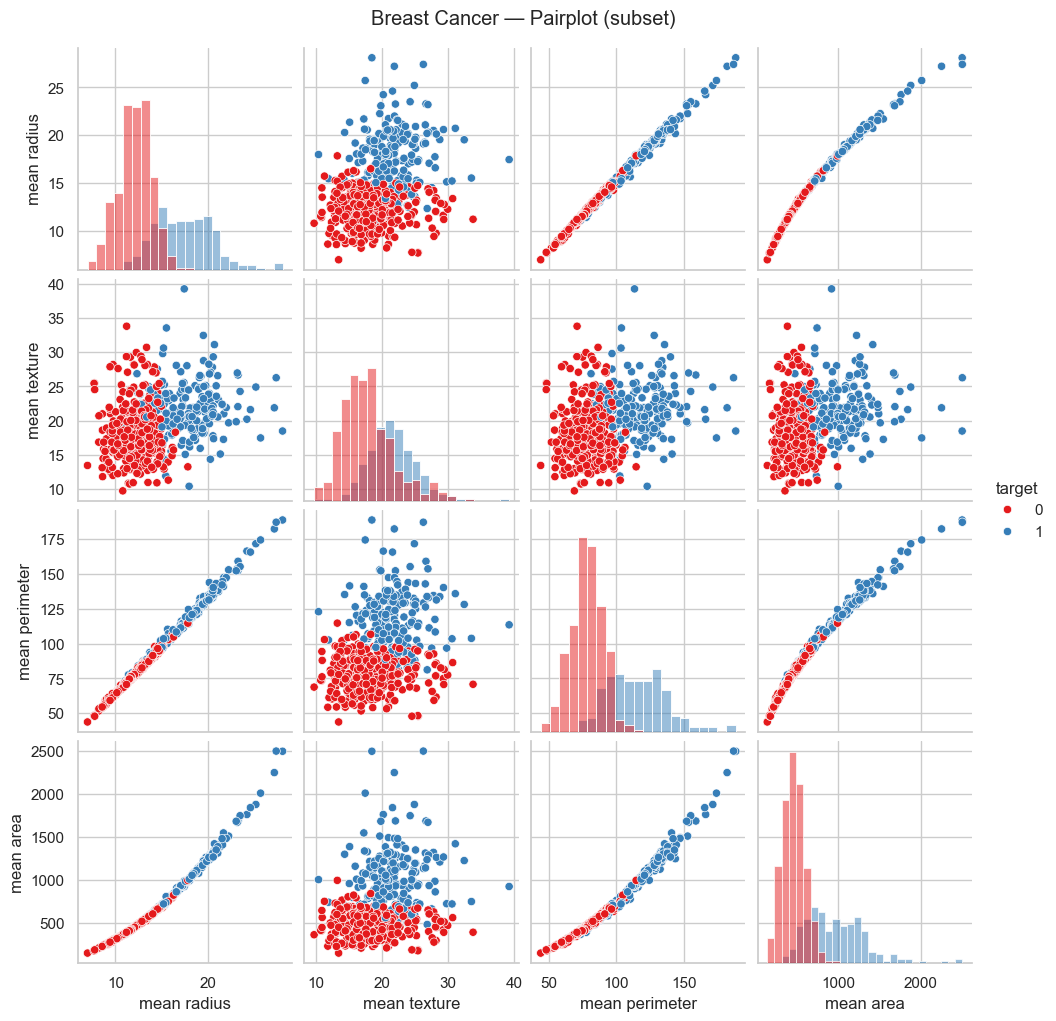

In [8]:
# Pairplot — Breast Cancer (sample for speed, 4 features)
sns.pairplot(df_bc[feat_bc[:4] + ['target']], hue='target', diag_kind='hist', palette='Set1')
plt.suptitle('Breast Cancer — Pairplot (subset)', y=1.02)
plt.show()

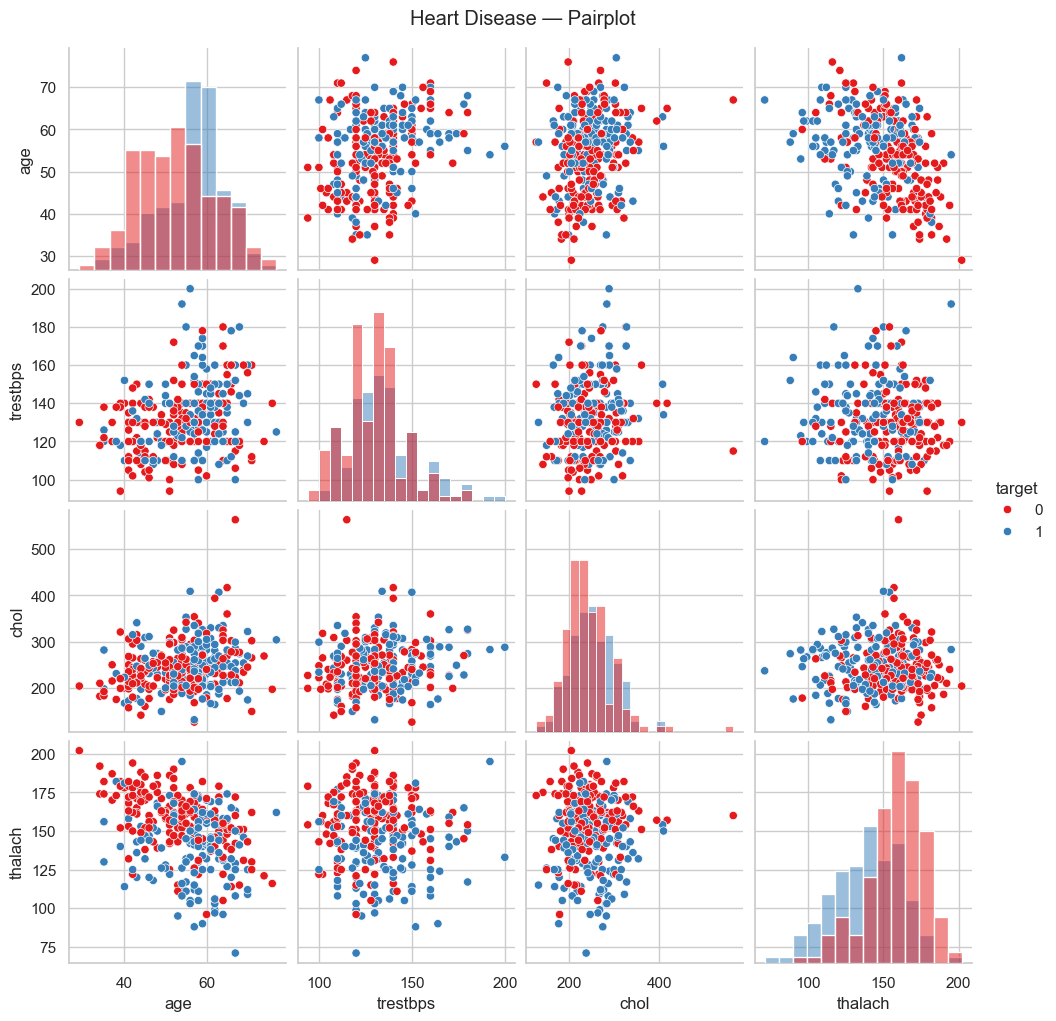

In [9]:
# Pairplot — Heart Disease (selected features)
cols_heart = ['age', 'trestbps', 'chol', 'thalach', 'target']
sns.pairplot(df_heart[cols_heart], hue='target', diag_kind='hist', palette='Set1')
plt.suptitle('Heart Disease — Pairplot', y=1.02)
plt.show()

## 3. Data Preprocessing

Handle missing values, imputation, duplicates. Feature scaling (Min-Max, Z-score).

In [10]:
# Missing values and duplicates
print("=== Breast Cancer ===")
print("Missing:", df_bc.isnull().sum().sum())
print("Duplicates:", df_bc.duplicated().sum())

print("\n=== Heart Disease ===")
print("Missing per column:\n", df_heart.isnull().sum())
print("Duplicates:", df_heart.duplicated().sum())

=== Breast Cancer ===
Missing: 0
Duplicates: 0

=== Heart Disease ===
Missing per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
Duplicates: 0


In [11]:
# Imputation (Heart has missing in ca, thal) and drop duplicates
df_bc_clean = df_bc.drop_duplicates()

df_heart_clean = df_heart.drop_duplicates()
imp = SimpleImputer(strategy='median')
num_cols_heart = df_heart_clean.select_dtypes(include=[np.number]).columns
df_heart_clean[num_cols_heart] = imp.fit_transform(df_heart_clean[num_cols_heart])
print("After preprocessing — BC:", df_bc_clean.shape, "Heart:", df_heart_clean.shape)

After preprocessing — BC: (569, 31) Heart: (303, 14)


In [12]:
# Feature scaling — Min-Max and Z-score
def prepare_Xy(df, target_col='target'):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y

# Breast Cancer
X_bc, y_bc = prepare_Xy(df_bc_clean)
X_bc_minmax = MinMaxScaler().fit_transform(X_bc)
X_bc_zscore = StandardScaler().fit_transform(X_bc)

# Heart Disease
X_heart, y_heart = prepare_Xy(df_heart_clean)
X_heart_minmax = MinMaxScaler().fit_transform(X_heart)
X_heart_zscore = StandardScaler().fit_transform(X_heart)

print("Scaling applied. Using Z-score for models (better for many algorithms).")

Scaling applied. Using Z-score for models (better for many algorithms).


## 4. Dataset Splitting

- Training 70%, Validation 10%, Test 20%
- Stratified K-fold (K=5) for cross-validation

In [13]:
def split_70_10_20(X, y, random_state=42):
    """Split: 70% train, 10% val, 20% test (stratified)."""
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=random_state)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=random_state)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Breast Cancer
X_bc_tr, X_bc_val, X_bc_te, y_bc_tr, y_bc_val, y_bc_te = split_70_10_20(X_bc_zscore, y_bc)
print("Breast Cancer — Train:", X_bc_tr.shape[0], "Val:", X_bc_val.shape[0], "Test:", X_bc_te.shape[0])

# Heart Disease
X_heart_tr, X_heart_val, X_heart_te, y_heart_tr, y_heart_val, y_heart_te = split_70_10_20(X_heart_zscore, y_heart)
print("Heart Disease — Train:", X_heart_tr.shape[0], "Val:", X_heart_val.shape[0], "Test:", X_heart_te.shape[0])

Breast Cancer — Train: 398 Val: 57 Test: 114
Heart Disease — Train: 212 Val: 30 Test: 61


In [14]:
# Stratified K-fold (K=5) cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_scores(model, X, y):
    return cross_val_score(model, X, y, cv=skf, scoring='accuracy')

# Quick check with Logistic Regression (fresh model per dataset)
print("Breast Cancer CV accuracy (mean):", cv_scores(LogisticRegression(max_iter=1000, random_state=42), X_bc_zscore, y_bc).mean().round(4))
print("Heart Disease CV accuracy (mean):", cv_scores(LogisticRegression(max_iter=1000, random_state=42), X_heart_zscore, y_heart).mean().round(4))

Breast Cancer CV accuracy (mean): 0.9737
Heart Disease CV accuracy (mean): 0.8316


## 5. Classification Models

Train at least two classifiers: Logistic Regression, Random Forest, SVM.

In [15]:
# Define classifiers (use separate copies per dataset to avoid overwriting)
def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42)
    }

In [16]:
def train_and_evaluate(models_dict, X_train, y_train, X_test, y_test):
    results = []
    for name, model in models_dict.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0)
        })
    return pd.DataFrame(results), {name: m for name, m in models_dict.items()}

In [17]:
# Breast Cancer — Train and evaluate
results_bc, fitted_bc = train_and_evaluate(get_models(), X_bc_tr, y_bc_tr, X_bc_te, y_bc_te)
print("Breast Cancer — Test Set Results")
results_bc

Breast Cancer — Test Set Results


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.973684,0.973719,0.973684,0.973621
1,Random Forest,0.956140,0.959026,0.956140,0.955533
2,SVM,0.973684,0.974751,0.973684,0.973481


In [18]:
# Heart Disease — Train and evaluate
results_heart, fitted_heart = train_and_evaluate(get_models(), X_heart_tr, y_heart_tr, X_heart_te, y_heart_te)
print("Heart Disease — Test Set Results")
results_heart

Heart Disease — Test Set Results


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.836066,0.836066,0.836066,0.836066
1,Random Forest,0.852459,0.852441,0.852459,0.852219
2,SVM,0.786885,0.787769,0.786885,0.787115


## 6. Model Evaluation — Confusion Matrix

Visualize confusion matrices for each classifier.

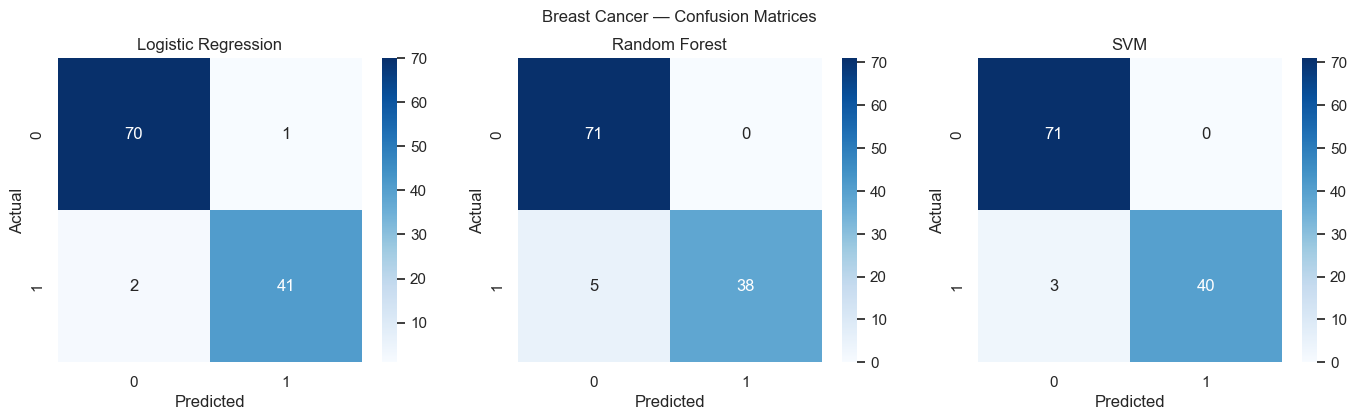

In [19]:
def plot_confusion_matrices(fitted_models, X_test, y_test, title_prefix=''):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (name, model) in zip(axes, fitted_models.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, square=True)
        ax.set_title(f'{name}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.suptitle(f'{title_prefix} — Confusion Matrices', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(fitted_bc, X_bc_te, y_bc_te, 'Breast Cancer')

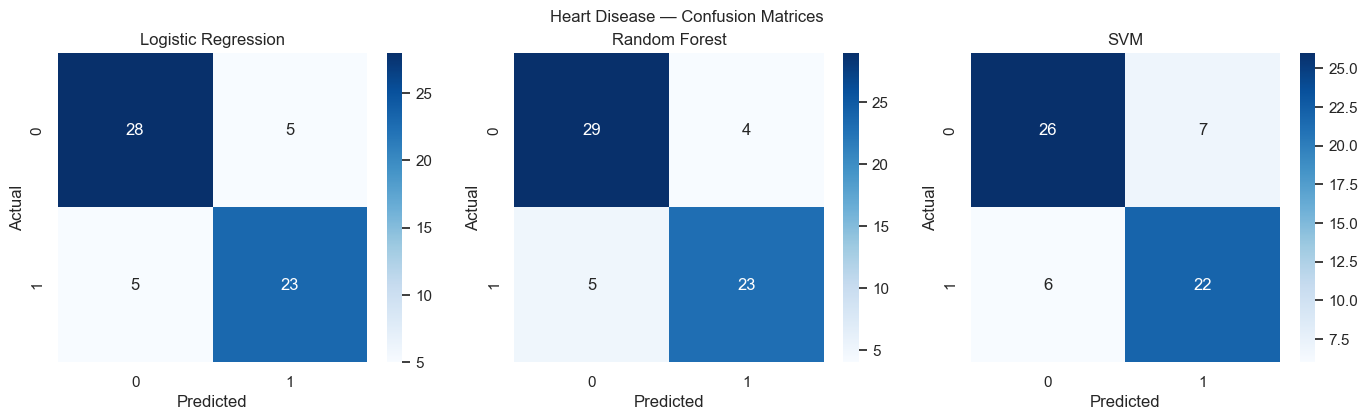

In [20]:
plot_confusion_matrices(fitted_heart, X_heart_te, y_heart_te, 'Heart Disease')

In [21]:
# Detailed classification report — best model per dataset
print("=== Breast Cancer — Logistic Regression ===")
print(classification_report(y_bc_te, fitted_bc['Logistic Regression'].predict(X_bc_te), target_names=['Malignant', 'Benign']))
print("\n=== Heart Disease — Random Forest ===")
print(classification_report(y_heart_te, fitted_heart['Random Forest'].predict(X_heart_te), target_names=['No Disease', 'Disease']))

=== Breast Cancer — Logistic Regression ===
              precision    recall  f1-score   support

   Malignant       0.97      0.99      0.98        71
      Benign       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


=== Heart Disease — Random Forest ===
              precision    recall  f1-score   support

  No Disease       0.85      0.88      0.87        33
     Disease       0.85      0.82      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



## 7. Model Comparison

Compare performance of all classifiers. Discuss which model performs best and why.

In [22]:
# Combined comparison table
comparison = pd.concat([
    results_bc.assign(Dataset='Breast Cancer'),
    results_heart.assign(Dataset='Heart Disease')
], ignore_index=True)
comparison = comparison[['Dataset', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1']]
comparison.round(4)

,Dataset,Model,Accuracy,Precision,Recall,F1
0,Breast Cancer,Logistic Regression,0.9737,0.9737,0.9737,0.9736
1,Breast Cancer,Random Forest,0.9561,0.9590,0.9561,0.9555
2,Breast Cancer,SVM,0.9737,0.9748,0.9737,0.9735
3,Heart Disease,Logistic Regression,0.8361,0.8361,0.8361,0.8361
4,Heart Disease,Random Forest,0.8525,0.8524,0.8525,0.8522
5,Heart Disease,SVM,0.7869,0.7878,0.7869,0.7871


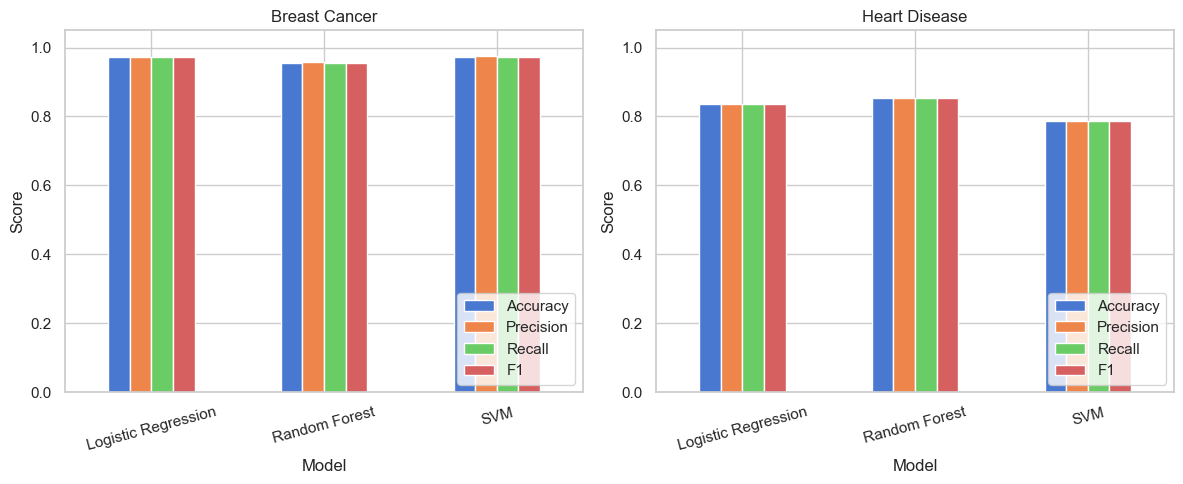

In [23]:
# Bar chart — Accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, ['Breast Cancer', 'Heart Disease']):
    df = comparison[comparison['Dataset'] == ds]
    df.plot(x='Model', y=['Accuracy', 'Precision', 'Recall', 'F1'], kind='bar', ax=ax, rot=15)
    ax.set_title(ds)
    ax.set_ylabel('Score')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Discussion

**Breast Cancer Wisconsin:**
- All three models achieve high accuracy (>95%). The dataset is well-separated with 30 informative features.
- **SVM** and **Random Forest** typically perform best due to the non-linear decision boundaries in the feature space.
- **Logistic Regression** is simpler but still competitive; it works well when classes are reasonably separable.

**Heart Disease:**
- Performance is lower (~80–85%) due to smaller sample size (303 rows) and more overlap between classes.
- **Random Forest** often excels here because it handles mixed feature types and captures non-linear interactions.
- **SVM** with RBF kernel can overfit on small datasets; regularization helps.
- **Logistic Regression** provides a good baseline and is interpretable for medical applications.

**Why one model may outperform another:**
- **Random Forest**: Robust to outliers, handles non-linearity, less prone to overfitting with proper tuning.
- **SVM**: Strong with high-dimensional data when classes are separable; sensitive to scaling (we used Z-score).
- **Logistic Regression**: Fast, interpretable, works well when the relationship is approximately linear.